In [2]:
from envs.env_module import EnvDataModule

problem_sig = "tsp"
n_cities = 20
k_sparse = 10
batch_size = 4

env_data_module = EnvDataModule(
    problem_sig=problem_sig,
    n_particles=10,
    device="cpu",
    eval_n_starts=1.0,
    training_cfg={"batch_size": batch_size, "n_cities": n_cities, "k_sparse": k_sparse},
    validation_cfg={"n_cities": n_cities, "k_sparse": k_sparse, "batch_size": batch_size},
    test_cfg={"n_cities": n_cities, "k_sparse": k_sparse, "batch_size": batch_size}
)
train_dataloader = env_data_module.train_dataloader()
val_dataloader = env_data_module.val_dataloader()

>>> n_cities to k_sparse mapping for TSP validation datasets: {20: 10}
>>> Validation datasets for TSP prepared:
    - 20_file: 25 instances
    - 20_random: 25 instances


In [3]:
val_dataloader = env_data_module.val_dataloader()
val_dataloader_idx2name = env_data_module.val_dataloader_idx2name
for idx, dataloader in enumerate(val_dataloader):
    print(f"Validation dataloader {idx}: {val_dataloader_idx2name[idx]}")
    for env in dataloader:
        obs, info = env.reset()
        print(env.val_gbest)
        break


Validation dataloader 0: 20_file
tensor([6.9194, 5.7549, 5.9916, 6.6171])
Validation dataloader 1: 20_random
tensor([5.9593, 5.9622, 6.4223, 5.9511])


In [4]:
env.population.shape

torch.Size([4, 10, 200])

In [5]:
print(f"pop: {env.population.shape}")
print(f"velo: {env.velocity.shape}")
print(f"pbest: {env.pbest.shape}")
print(f"gbest: {env.gbest.shape}")
print(f"val_pbest: {env.val_pbest.shape}")
print(f"val_gbest: {env.val_gbest.shape}")

pop: torch.Size([4, 10, 200])
velo: torch.Size([4, 10, 200])
pbest: torch.Size([4, 10, 200])
gbest: torch.Size([4, 200])
val_pbest: torch.Size([4, 10])
val_gbest: torch.Size([4])


In [36]:
paths, costs = env.decode_solutions_eval()

In [37]:
paths.shape, costs.shape

(torch.Size([4, 128, 20]), torch.Size([4, 128]))

In [6]:
import torch

d = torch.load("/home/longth/projects/deeppso/envs/data/tsp/testDataset-20.pt")
d.shape

torch.Size([1280, 20, 2])

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
population_stats_file = "logs/tsp/version_1/population_stats.csv"
df = pd.read_csv(population_stats_file)
df.head()

,validation_epoch,dataloader_key,env_idx,pso_idx,population_costs
0,0,20_file,0,0,"[5.940244197845459, 5.9727067947387695, 5.7391..."
1,0,20_file,1,0,"[4.667680740356445, 5.2100019454956055, 4.5246..."
2,0,20_file,2,0,"[5.6640825271606445, 4.974301815032959, 5.3852..."
3,0,20_file,3,0,"[5.724636077880859, 6.145621299743652, 5.82690..."
4,0,20_file,0,1,"[5.40872859954834, 5.784636497497559, 5.720457..."


In [4]:
## Print unique values of dataloader_key, env_idx, validation_epoch
print("Unique dataloader_key values:", df["dataloader_key"].unique())
print("Unique env_idx values:", df["env_idx"].unique())
print("Unique validation_epoch values:", df["validation_epoch"].unique())

Unique dataloader_key values: ['20_file']
Unique env_idx values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
Unique validation_epoch values: [0 1 2 3 4 5 6 7 8 9]


## Plots

What is the minimum, p25, p50, p75, max value of the cost of the population at each PSO interation? 

Initial data loaded, total rows: 64000
<> Data filtered for validation_epoch=0, remaining rows: 6400


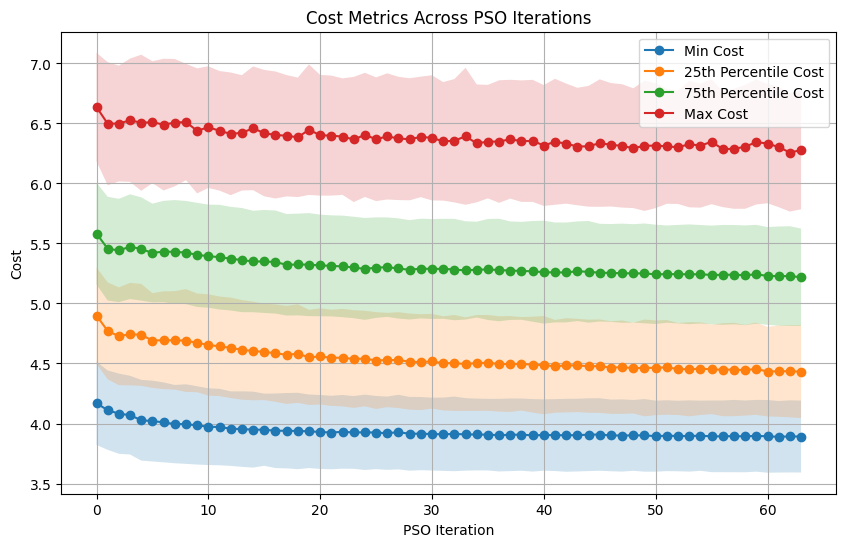

In [ ]:
specified_dataloaded_key = None
specified_env_idx = None
specified_validation_epoch = 0

subset_df = df.copy()
print(f"Initial data loaded, total rows: {len(subset_df)}")
if specified_dataloaded_key is not None:
    subset_df = subset_df[subset_df["dataloader_key"] == specified_dataloaded_key].copy()
    assert len(subset_df) > 0, f"No data found for dataloader_key={specified_dataloaded_key}"
    print(f"<> Data filtered for dataloader_key={specified_dataloaded_key}, remaining rows: {len(subset_df)}")
if specified_env_idx is not None:    
    subset_df = subset_df[subset_df["env_idx"] == specified_env_idx].copy()
    assert len(subset_df) > 0, f"No data found for env_idx={specified_env_idx}"
    print(f"<> Data filtered for env_idx={specified_env_idx}, remaining rows: {len(subset_df)}")
if specified_validation_epoch is not None:
    subset_df = subset_df[subset_df["validation_epoch"] == specified_validation_epoch].copy()
    assert len(subset_df) > 0, f"No data found for validation_epoch={specified_validation_epoch}"
    print(f"<> Data filtered for validation_epoch={specified_validation_epoch}, remaining rows: {len(subset_df)}")

# Extract analyzable population costs from the subset dataframe
costs_raw_val = subset_df["population_costs"].values
costs_list = [eval(cost_str) for cost_str in costs_raw_val]
min_costs = [min(costs) for costs in costs_list]
p25_costs = [np.quantile(costs, 0.25) for costs in costs_list]
p75_costs = [np.quantile(costs, 0.75) for costs in costs_list]
max_costs = [max(costs) for costs in costs_list]

subset_df["min_cost"] = min_costs
subset_df["p25_cost"] = p25_costs
subset_df["p75_cost"] = p75_costs
subset_df["max_cost"] = max_costs

# Taking mean of values accross PSO iterations 
mean_subset_df = subset_df.groupby("pso_idx").agg({
    "min_cost": "mean",
    "p25_cost": "mean",
    "p75_cost": "mean",
    "max_cost": "mean",
}).reset_index()

std_subset_df = subset_df.groupby("pso_idx").agg({
    "min_cost": "std",
    "p25_cost": "std",
    "p75_cost": "std",
    "max_cost": "std",
}).reset_index()

# Plotting mean and std of costs across PSO iterations
plt.figure(figsize=(10, 6))
plt.plot(mean_subset_df["pso_idx"], mean_subset_df["min_cost"], label="Min Cost", marker="o")
plt.plot(mean_subset_df["pso_idx"], mean_subset_df["p25_cost"], label="25th Percentile Cost", marker="o")
plt.plot(mean_subset_df["pso_idx"], mean_subset_df["p75_cost"], label="75th Percentile Cost", marker="o")
plt.plot(mean_subset_df["pso_idx"], mean_subset_df["max_cost"], label="Max Cost", marker="o")
plt.fill_between(mean_subset_df["pso_idx"], mean_subset_df["min_cost"] - std_subset_df["min_cost"], mean_subset_df["min_cost"] + std_subset_df["min_cost"], alpha=0.2)
plt.fill_between(mean_subset_df["pso_idx"], mean_subset_df["p25_cost"] - std_subset_df["p25_cost"], mean_subset_df["p25_cost"] + std_subset_df["p25_cost"], alpha=0.2)
plt.fill_between(mean_subset_df["pso_idx"], mean_subset_df["p75_cost"] - std_subset_df["p75_cost"], mean_subset_df["p75_cost"] + std_subset_df["p75_cost"], alpha=0.2)
plt.fill_between(mean_subset_df["pso_idx"], mean_subset_df["max_cost"] - std_subset_df["max_cost"], mean_subset_df["max_cost"] + std_subset_df["max_cost"], alpha=0.2)  
# plt.axhline(gbest_cost, color="red", linestyle="--", label="Global Best Cost")
plt.xlabel("PSO Iteration")
plt.ylabel("Cost")
plt.title("Cost Metrics Across PSO Iterations")
plt.legend()
plt.grid()
plt.show()

In [10]:
subset_df[["env_idx", "pso_idx", "min_cost", "p25_cost", "p75_cost", "max_cost"]].to_csv("temp.csv", index=False)